<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/07_cLab_TcEstudiante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio — Determinación de la temperatura crítica del modelo de Ising 2D con redes neuronales de *scikit-learn*

**Maestría en Computación Científica · Módulo de Redes Neuronales · Modelo de Ising 2D**

En este laboratorio vas a **entrenar una red neuronal clasificadora con `scikit-learn`** y a
usarla como un *termómetro* para localizar la **temperatura crítica** $T_c$ de la transición
de fase ferromagnética del modelo de Ising en 2D.



## Objetivos de aprendizaje

Al terminar este laboratorio serás capaz de:

1. Entrenar un clasificador de red neuronal con `sklearn.neural_network.MLPClassifier`,
   identificando el papel de cada hiperparámetro.
2. **Contrastar la API de `scikit-learn` 
3. Usar un clasificador entrenado **lejos** de la transición para estimar la fase
   (ordenada / desordenada) a temperaturas **cercanas** a $T_c$.
4. Estimar $T_c$ a partir del cruce $\langle P(y{=}1\mid X)\rangle = 0.5$, cuantificar su
   incertidumbre entre realizaciones y compararla con el valor exacto de Onsager.

## 1. Física: transición de fase del modelo de Ising 2D

El modelo de Ising 2D en una red $L\times L$ con acoplamiento ferromagnético $J>0$ tiene energía

$$E(\{s\}) = -J \sum_{\langle i,j\rangle} s_i\, s_j, \qquad s_i \in \{-1, +1\},$$

donde la suma es sobre pares de primeros vecinos. En unidades $J = k_B = 1$, el sistema infinito
presenta una transición de fase de segundo orden a la **temperatura crítica de Onsager**

$$T_c = \frac{2}{\ln\!\left(1+\sqrt{2}\right)} \approx 2.269.$$

- $T < T_c$: **fase ordenada** (ferromagnética), magnetización por sitio $|m|$ grande.
- $T > T_c$: **fase desordenada** (paramagnética), $|m|\approx 0$.

**Idea del laboratorio** (Carrasquilla & Melko, *Nature Physics* **13**, 431 (2017)): un
clasificador entrenado solo con configuraciones *claramente* ordenadas ($y=0$) y *claramente*
desordenadas ($y=1$) aprende una frontera de decisión que, evaluada en configuraciones cercanas
a $T_c$, se comporta como un **parámetro de orden efectivo**. La temperatura donde
$\langle P(y{=}1\mid X)\rangle = 0.5$ estima $T_c$.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42
np.random.seed(RNG)

## 3. Datos: configuraciones lejos de $T_c$

`ising_dataset.npz` contiene configuraciones de espines de una red $16\times 16$ con frontera
periódica, generadas por Monte Carlo (Metrópolis). Campos:

| Campo | Forma | Significado |
|---|---|---|
| `X` | `(1600, 16, 16)` | Configuraciones de espines $s_i \in \{-1,+1\}$ |
| `y` | `(1600,)` | Etiqueta de fase: `0` = ordenada ($T$ baja), `1` = desordenada ($T$ alta) |
| `T` | `(1600,)` | Temperatura de cada configuración |
| `m` | `(1600,)` | Magnetización por sitio $|m|$ |
| `realizacion` | `(1600,)` | Índice de cadena Monte Carlo independiente (`0..3`) |
| `Tc`, `L`, `frontera` | escalares | Metadatos ($T_c$ exacto, tamaño, tipo de frontera) |

Las temperaturas de entrenamiento **evitan** la región crítica: hay un hueco entre
$T=1.9$ y $T=2.6$.

In [6]:
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

Tc_exacto = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, "->", np.unique(y, return_counts=True))
print("realizaciones:", np.unique(realizacion))
print("Tc exacto (Onsager):", Tc_exacto)

X: (1600, 16, 16) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022


### Ejercicio 1 — Exploración

Responde con código y en una celda de texto:

1. ¿Qué temperaturas tienen etiqueta `y = 0` y cuáles `y = 1`? ¿Dónde está el "hueco"?
2. ¿Está balanceado el problema (cuántas configuraciones por clase)?
3. Grafica el histograma de $|m|$ separando por clase. ¿Se separan bien las dos fases?

In [7]:
# --- Ejercicio 1  ---


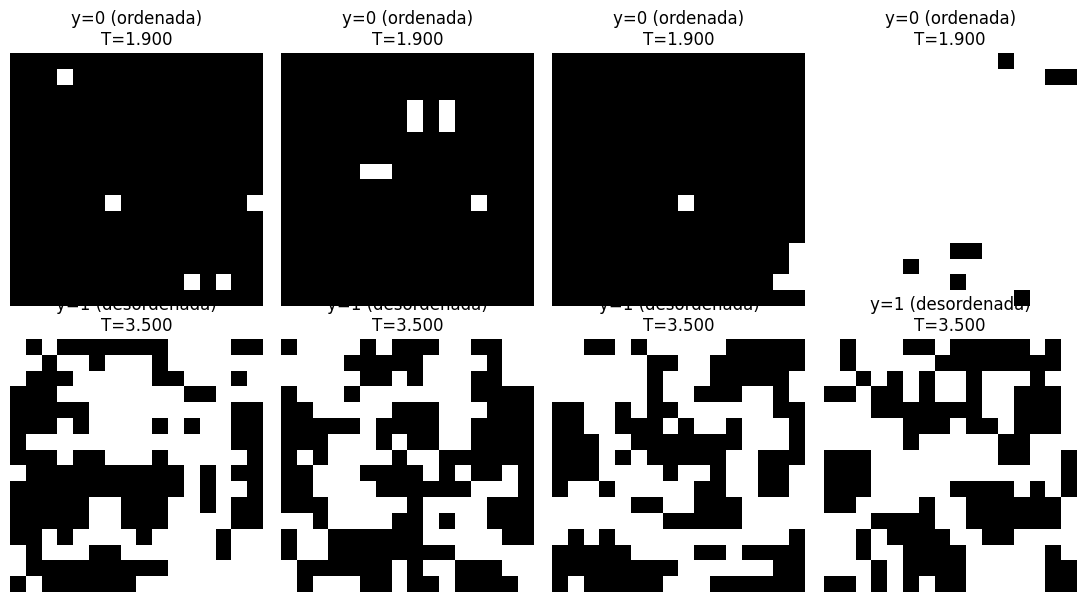

In [8]:
# Configuraciones típicas a T baja y T alta
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, (cls, titulo) in enumerate([(0, "ordenada"), (1, "desordenada")]):
    idx = np.where(y == cls)[0][:4]
    for k, i in enumerate(idx):
        axes[row, k].imshow(X[i], cmap="gray", vmin=-1, vmax=1)
        axes[row, k].set_title(f"y={cls} ({titulo})\nT={T[i]:.3f}")
        axes[row, k].axis("off")
plt.tight_layout()
plt.show()

## 4. Partición de los datos: por **realización**

Las configuraciones de una misma cadena Monte Carlo (`realizacion`) están **correlacionadas**
temporalmente. Si mezcláramos al azar, configuraciones casi idénticas caerían en *train* y en
*test* a la vez → fuga de información y métricas infladas.

Partimos por realización:

- **Entrenamiento:** realizaciones `0` y `1`
- **Validación:** realización `2`
- **Prueba:** realización `3`

Además aplanamos cada configuración $16\times16 \to 256$ porque `MLPClassifier` espera
vectores de características.

### Ejercicio 2 — Construir los conjuntos

Completa las máscaras y los arreglos aplanados. Deberías obtener
`X_train (800, 256)`, `X_val (400, 256)` y `X_test (400, 256)`.

In [ ]:
# --- Ejercicio 2  ---
mask_train = np.isin(realizacion, [0, 1])
mask_val   = realizacion == 2
mask_test  = realizacion == 3

def aplanar(A):
    return A.reshape(A.shape[0], L * L)

X_train, y_train, T_train = aplanar(X[mask_train]), y[mask_train], T[mask_train]
X_val,   y_val,   T_val   = aplanar(X[mask_val]),   y[mask_val],   T[mask_val]
X_test,  y_test,  T_test  = aplanar(X[mask_test]),  y[mask_test],  T[mask_test]

for nombre, Xs, ys in [("train", X_train, y_train),
                       ("val",   X_val,   y_val),
                       ("test",  X_test,  y_test)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

train  X=(800, 256)  y=(800,)  clases=[400 400]
val    X=(400, 256)  y=(400,)  clases=[200 200]
test   X=(400, 256)  y=(400,)  clases=[200 200]


## 5. Entrenar el `MLPClassifier`

| Argumento | Valor | Qué controla |
|---|---|---|
| `hidden_layer_sizes=(16, 8, 4)` | 3 capas ocultas | Arquitectura: 256 → 16 → 8 → 4 → 2 |
| `activation="relu"` | ReLU | No linealidad de las capas ocultas |
| `solver="adam"` | Adam | Optimizador basado en gradiente estocástico |
| `learning_rate_init=0.001` | 0.001 | Tamaño de paso inicial |
| `max_iter=1000` | 1000 | Máximo de épocas (puede parar antes por tolerancia) |
| `random_state=42` | 42 | Reproducibilidad (init de pesos y *shuffling*) |

> La capa de salida (2 neuronas, *softmax*) y la pérdida (*log-loss*) las añade `scikit-learn`
> automáticamente al ver que `y` tiene dos clases enteras. En `NN_Cero.ipynb` esto era la
> `sigmoide` final + `cost_Function`; en PyTorch era `nn.Linear(..., 1)` + `BCEWithLogitsLoss`.

### Ejercicio 3 — Instanciar, entrenar y evaluar

1. Crea el modelo con los hiperparámetros de la tabla y ajústalo con `X_train, y_train`.
2. Reporta *accuracy* en train / val / test con `.score(...)`.
3. Grafica `model.loss_curve_` (la pérdida por época que `scikit-learn` guarda).

iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875


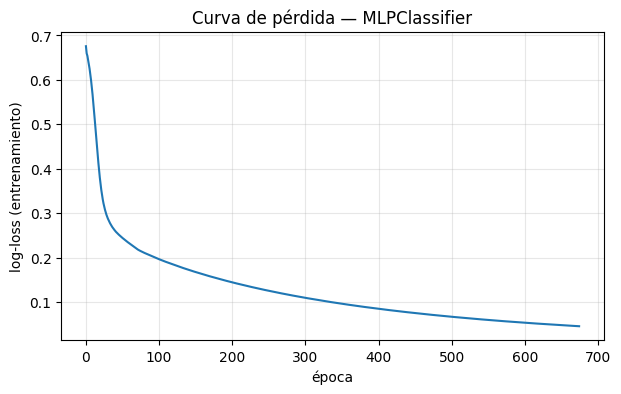

In [ ]:
# --- Ejercicio 3  ---
model = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)
model.fit(X_train, y_train)

acc = {
    "train": model.score(X_train, y_train),
    "val":   model.score(X_val,   y_val),
    "test":  model.score(X_test,  y_test),
}
print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
for k, v in acc.items():
    print(f"accuracy {k:5s}: {v:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(model.loss_curve_)
plt.xlabel("época")
plt.ylabel("log-loss (entrenamiento)")
plt.title("Curva de pérdida — MLPClassifier")
plt.grid(alpha=0.3)
plt.show()

### Reflexión (sección 5)

- El *accuracy* de entrenamiento suele ser `1.0000`. ¿Es esto sobreajuste preocupante, dado que
  train / val / test dan valores parecidos? ¿Por qué este problema es "fácil" **lejos** de $T_c$?
- ¿Qué esperas que ocurra con las probabilidades del modelo **cerca** de $T_c$, donde no vio datos?

## 6. El clasificador como termómetro

Para una configuración $X$, `model.predict_proba(X)[:, 1]` es $P(y{=}1\mid X)$: la "confianza"
del modelo en que la configuración pertenece a la **fase desordenada**.

Promediando sobre muchas configuraciones a temperatura fija $T$ obtenemos una curva
$\langle P(y{=}1\mid X)\rangle(T)$ que va de $\approx 0$ (ordenado) a $\approx 1$ (desordenado).
Definimos la estimación de $T_c$ como la temperatura del **cruce por 0.5**.

## 7. Datos de barrido fino alrededor de $T_c$

`temperatura_critica.npz` contiene **6200** configuraciones $16\times16$ en **31 temperaturas**
entre 1.6 y 3.2 (más densas cerca de $T_c$), con 4 realizaciones. **No trae etiquetas de
entrenamiento:** solo `y_ref`, una etiqueta obtenida aplicando el $T_c$ exacto, que usaremos
**únicamente para verificar** (usarla para entrenar sería hacer trampa).

In [12]:
datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)
X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L)
T_tc = datos_tc["T"]
realizacion_tc = datos_tc["realizacion"]
y_ref_tc = datos_tc["y_ref"]

print("X_tc:", X_tc.shape)
print("temperaturas:", np.unique(T_tc))

# Probabilidad de la clase "desordenada" (y = 1)
idx1 = list(model.classes_).index(1)
p1_tc = model.predict_proba(X_tc)[:, idx1]

# Chequeo con y_ref (NO usar para entrenar)
pred_tc = (p1_tc >= 0.5).astype(int)
print("accuracy vs y_ref (solo verificacion):",
      round((pred_tc == y_ref_tc).mean(), 4))

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]


NameError: name 'model' is not defined

### Ejercicio 4 — Curva $\langle P\rangle$ vs $T$

Construye un `DataFrame` con columnas `T, realizacion, prob` y agrégalo por
`(realizacion, T)` para obtener la media y la desviación de `prob`. Grafica una curva por
realización y marca la línea $P = 0.5$.

In [13]:
# --- Ejercicio 4 ---
df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc})

resumen = (df.groupby(["realizacion", "T"])
             .agg(prob_media=("prob", "mean"),
                  prob_std=("prob", "std"),
                  N=("prob", "size"))
             .reset_index())

# Realizar el grafico

NameError: name 'p1_tc' is not defined

### Ejercicio 5 — Estimar $T_c$ por interpolación

Para cada realización, encuentra el primer par de temperaturas consecutivas donde
$\langle P\rangle$ cruza 0.5 e interpola linealmente:

$$T_c \approx T_i + (0.5 - P_i)\,\frac{T_{i+1}-T_i}{P_{i+1}-P_i}.$$

Luego promedia entre realizaciones y reporta la media, la desviación estándar y el error
estándar de la media (SEM).

In [ ]:
# --- Ejercicio 5  ---
def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

Tc_por_realizacion = []
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion.append(Tc_r)
    print(f"realización {r}:  Tc = {Tc_r:.4f}")

Tc_por_realizacion = np.array(Tc_por_realizacion)
Tc_est = np.nanmean(Tc_por_realizacion)
Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

print("\n" + "-" * 44)
print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f} (SEM)")
print(f"Tc Onsager     = {Tc_exacto:.4f}")
print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")

realización 0:  Tc = 2.2403
realización 1:  Tc = 2.2204
realización 2:  Tc = 2.2149
realización 3:  Tc = 2.2280

--------------------------------------------
Tc estimado    = 2.2259 +/- 0.0055 (SEM)
Tc Onsager     = 2.2692
error relativo = 1.91 %


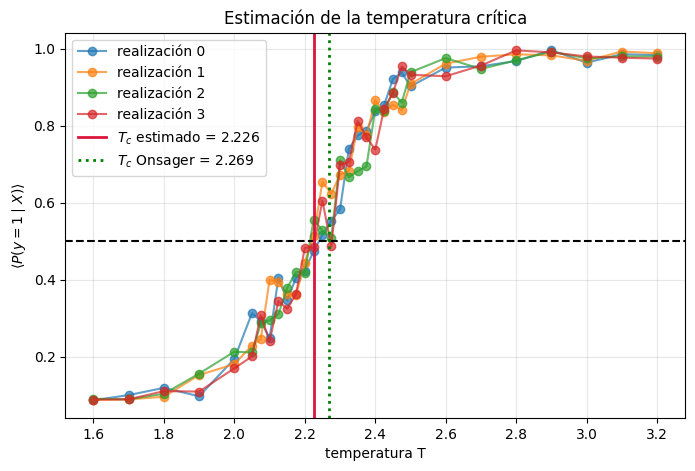

In [10]:
plt.figure(figsize=(8, 5))
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    plt.plot(d["T"], d["prob_media"], "o-", alpha=0.7, label=f"realización {r}")
plt.axhline(0.5, ls="--", color="k")
plt.axvline(Tc_est, ls="-", color="crimson", lw=2,
            label=fr"$T_c$ estimado = {Tc_est:.3f}")
plt.axvline(Tc_exacto, ls=":", color="green", lw=2,
            label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")
plt.xlabel("temperatura T")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Estimación de la temperatura crítica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Análisis crítico

Responde en celdas de texto, con evidencia (números o gráficas de tu notebook):

1. **Sesgo del estimador.** El $T_c$ estimado suele quedar *por debajo* de Onsager
   ($\approx 2.23$ vs $2.269$). Menciona al menos dos causas: tamaño finito $L=16$, definición
   de la etiqueta `y`, rango de temperaturas de entrenamiento, uso del umbral fijo 0.5.
2. **Arquitectura.** Repite el pipeline con `hidden_layer_sizes=(64,)` y con `(32, 16, 8)`.
   ¿Cambia $T_c$? ¿Cambia la *pendiente* de la curva en la transición?
3. **Reproducibilidad.** Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?
4. **Definición alternativa.** Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?
5. **Estandarización.** Los espines ya están en $\{-1,+1\}$. ¿Ayuda un `StandardScaler`?
   ¿Por qué sí o por qué no en este problema?

## 9. Reto  — Escalamiento con el tamaño del sistema

Con el programa de ising generar varias datos para diferentes tipo de redes L=10x10, L=15x15, L=20x20, L=25x25, L=30x30

1. Construye un conjunto de entrenamiento.
2. Entrena un nuevo `MLPClassifier`, repite los Ejercicios 4–5 y obtén $T_c(L=20)$.
3. Compara todas las $T_c$ ¿La estimación se acerca a Onsager al crecer $L$?
   Relaciónalo con el *finite-size scaling*.

In [ ]:
# Reto (opcional): esqueleto para L = 20


X20: (6200, 400)  L = 20
